In [1]:
import config
import torch
import sys
sys.path.append('../util')
sys.path.append('../others_networks')
sys.path.append('../UMergeNet')
from Trainer import Trainer
from util import show_dataset_prev
from GenericDatasetReader import get_datasets

from UMergeNet import ConvType, UMergeNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
result_path = './UMergeNet/'

In [2]:
num_classes  = config.num_classes
in_channels  = config.in_channels
out_channels = 1

train_loader, test_loader, val_loader = get_datasets(dataset_dir=config.dataset_path, 
                                              resolution=config.dataset_resolution, 
                                              batch_size=config.batch_size)

torch.Size([16, 3, 224, 224]) torch.Size([16, 1, 224, 224])
8701 97 98


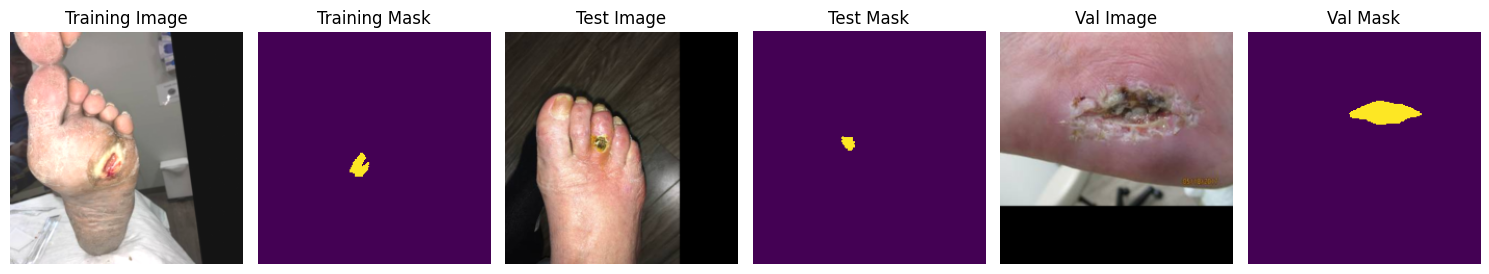

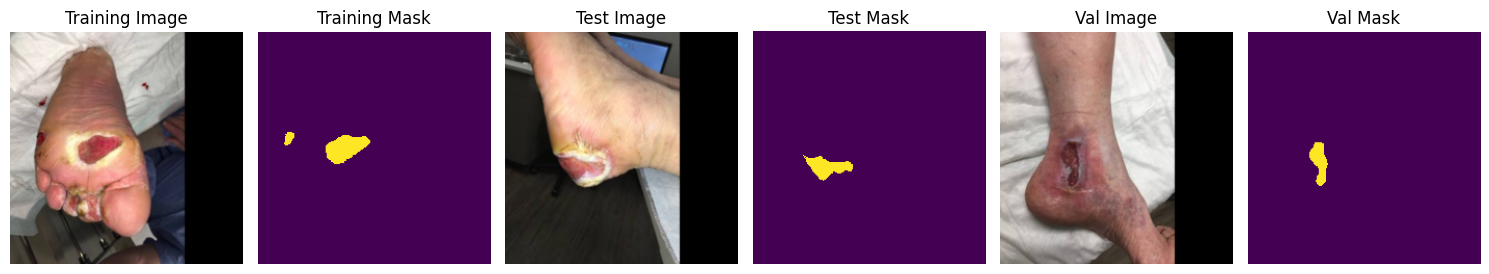

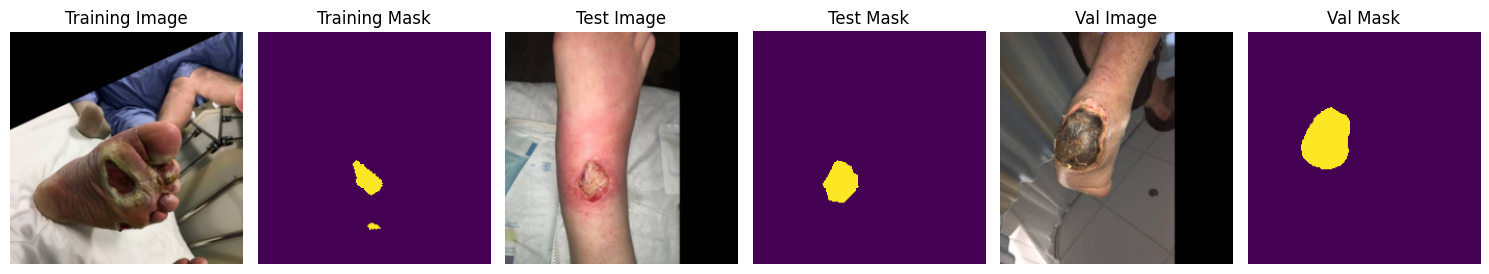

In [3]:
for (images_train, masks_train), (images_test, masks_test) in zip(train_loader, test_loader):
    print(images_train.shape, masks_train.shape)
    break

print(len(train_loader.dataset), len(test_loader.dataset), len(val_loader.dataset))

show_dataset_prev(train_loader, test_loader, val_loader, num_images=3)

In [4]:
def train(model, model_name=None, epochs=300, re_evaluate=True):
    model_filename = f'{model_name}-epochs{epochs}.pth'

    
    trainer = Trainer(num_classes=num_classes,
                    model_filename=model_filename, 
                    model_dir=result_path, 
                    save_xlsx=True)
    model = trainer.train(model, train_loader, val_loader, test_loader,
                            num_epochs=epochs, 
                            verbose=1, 
                            save_every=5, 
                            learning_rate=1e-3,
                            continue_from_last=True,
                            # we are re-evaluating after loading the model 
                            # because we refactored the code and want to see the new results
                            re_evaluate=re_evaluate)
    model.to(device)
    return trainer.get_best_test_stats()



# Axial

In [5]:
model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Axial)
stats1 = train(model, model_name='UMergeNet-axial-1')

Device: cuda
Trainable_parameters: 1726801
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UMergeNet//UMergeNet-axial-1-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9513 mIoU: 0.9118 Prec: 0.9485 Recall: 0.9548 Q: 0.8678
Loading best version.
Loaded model: ./UMergeNet//UMergeNet-axial-1-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9534 mIoU: 0.9152 Prec: 0.9532 Recall: 0.9541 Q: 0.8728
Best version has the best f1-score on [testset]: best(0.9534) latest(0.9513)
Best version loaded.


In [6]:
model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Axial)
stats2 = train(model, model_name='UMergeNet-axial-2')

Device: cuda
Trainable_parameters: 1726801
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UMergeNet//UMergeNet-axial-2-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9541 mIoU: 0.9164 Prec: 0.9513 Recall: 0.9571 Q: 0.8747
Loading best version.
Loaded model: ./UMergeNet//UMergeNet-axial-2-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9490 mIoU: 0.9079 Prec: 0.9513 Recall: 0.9471 Q: 0.8619
Latest version has the best f1-score on [testset]: latest(0.9541) best(0.9490)
Loaded model: ./UMergeNet//UMergeNet-axial-2-epochs300.pth
Latest version loaded.


In [7]:
model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Axial)
stats3 = train(model, model_name='UMergeNet-axial-3')

Device: cuda
Trainable_parameters: 1726801
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UMergeNet//UMergeNet-axial-3-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9514 mIoU: 0.9120 Prec: 0.9537 Recall: 0.9499 Q: 0.8681
Loading best version.
Loaded model: ./UMergeNet//UMergeNet-axial-3-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9474 mIoU: 0.9052 Prec: 0.9571 Recall: 0.9389 Q: 0.8580
Latest version has the best f1-score on [testset]: latest(0.9514) best(0.9474)
Loaded model: ./UMergeNet//UMergeNet-axial-3-epochs300.pth
Latest version loaded.


In [8]:
print("UMergeNet Axial")
print("AVG F1-Score:", round((stats1['f1']+stats2['f1']+stats3['f1'])/3.0,3) )
print("Max F1-Score:", round(max(stats1['f1'],stats2['f1'],stats3['f1']),3) )

print("AVG mIoU:", round((stats1['miou']+stats2['miou']+stats3['miou'])/3.0,3) )
print("AVG mIoU:", round(max(stats1['miou'],stats2['miou'],stats3['miou']),3) )

UMergeNet Axial
AVG F1-Score: 0.953
Max F1-Score: 0.954
AVG mIoU: 0.914
AVG mIoU: 0.916


# Axial DW

In [9]:
model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Axial, encoder_groups='dw', decoder_groups='dw', merger_groups='dw')
stats1 = train(model, model_name='UMergeNet-axial-dw-1')

Device: cuda
Trainable_parameters: 685497
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UMergeNet//UMergeNet-axial-dw-1-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9480 mIoU: 0.9060 Prec: 0.9472 Recall: 0.9492 Q: 0.8591
Loading best version.
Loaded model: ./UMergeNet//UMergeNet-axial-dw-1-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9490 mIoU: 0.9078 Prec: 0.9457 Recall: 0.9530 Q: 0.8618
Best version has the best f1-score on [testset]: best(0.9490) latest(0.9480)
Best version loaded.


In [10]:
model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Axial, encoder_groups='dw', decoder_groups='dw', merger_groups='dw')
stats2 = train(model, model_name='UMergeNet-axial-dw-2')

Device: cuda
Trainable_parameters: 685497
Loss function: Losses.BCEDiceLoss


Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UMergeNet//UMergeNet-axial-dw-2-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9487 mIoU: 0.9070 Prec: 0.9534 Recall: 0.9449 Q: 0.8607
Loading best version.
Loaded model: ./UMergeNet//UMergeNet-axial-dw-2-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9488 mIoU: 0.9073 Prec: 0.9497 Recall: 0.9487 Q: 0.8610
Best version has the best f1-score on [testset]: best(0.9488) latest(0.9487)
Best version loaded.


In [11]:
model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Axial, encoder_groups='dw', decoder_groups='dw', merger_groups='dw')
stats3 = train(model, model_name='UMergeNet-axial-dw-3')

Device: cuda
Trainable_parameters: 685497
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UMergeNet//UMergeNet-axial-dw-3-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9502 mIoU: 0.9099 Prec: 0.9493 Recall: 0.9517 Q: 0.8649
Loading best version.
Loaded model: ./UMergeNet//UMergeNet-axial-dw-3-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9517 mIoU: 0.9123 Prec: 0.9533 Recall: 0.9506 Q: 0.8686
Best version has the best f1-score on [testset]: best(0.9517) latest(0.9502)
Best version loaded.


In [12]:
print("UMergeNet Axial Dw")
print("AVG F1-Score:", round((stats1['f1']+stats2['f1']+stats3['f1'])/3.0,3) )
print("Max F1-Score:", round(max(stats1['f1'],stats2['f1'],stats3['f1']),3) )

print("AVG mIoU:", round((stats1['miou']+stats2['miou']+stats3['miou'])/3.0,3) )
print("AVG mIoU:", round(max(stats1['miou'],stats2['miou'],stats3['miou']),3) )

UMergeNet Axial Dw
AVG F1-Score: 0.95
Max F1-Score: 0.952
AVG mIoU: 0.909
AVG mIoU: 0.912


# Atrous

In [13]:
model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Atrous)
stats1 = train(model, model_name='UMergeNet-atrous-1')

Device: cuda
Trainable_parameters: 2487385
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UMergeNet//UMergeNet-atrous-1-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9466 mIoU: 0.9040 Prec: 0.9535 Recall: 0.9404 Q: 0.8561
Loading best version.
Loaded model: ./UMergeNet//UMergeNet-atrous-1-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9470 mIoU: 0.9044 Prec: 0.9359 Recall: 0.9591 Q: 0.8568
Best version has the best f1-score on [testset]: best(0.9470) latest(0.9466)
Best version loaded.


In [14]:
model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Atrous)
stats2 = train(model, model_name='UMergeNet-atrous-2')

Device: cuda
Trainable_parameters: 2487385
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UMergeNet//UMergeNet-atrous-2-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9485 mIoU: 0.9072 Prec: 0.9521 Recall: 0.9454 Q: 0.8609
Loading best version.
Loaded model: ./UMergeNet//UMergeNet-atrous-2-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9476 mIoU: 0.9053 Prec: 0.9503 Recall: 0.9453 Q: 0.8580
Latest version has the best f1-score on [testset]: latest(0.9485) best(0.9476)
Loaded model: ./UMergeNet//UMergeNet-atrous-2-epochs300.pth
Latest version loaded.


In [15]:
model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Atrous)
stats3 = train(model, model_name='UMergeNet-atrous-3')

Device: cuda
Trainable_parameters: 2487385
Loss function: Losses.BCEDiceLoss


Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UMergeNet//UMergeNet-atrous-3-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9462 mIoU: 0.9032 Prec: 0.9504 Recall: 0.9426 Q: 0.8549
Loading best version.
Loaded model: ./UMergeNet//UMergeNet-atrous-3-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9426 mIoU: 0.8971 Prec: 0.9422 Recall: 0.9438 Q: 0.8458
Latest version has the best f1-score on [testset]: latest(0.9462) best(0.9426)
Loaded model: ./UMergeNet//UMergeNet-atrous-3-epochs300.pth
Latest version loaded.


In [16]:
print("UMergeNet Atrous")
print("AVG F1-Score:", round((stats1['f1']+stats2['f1']+stats3['f1'])/3.0,3) )
print("Max F1-Score:", round(max(stats1['f1'],stats2['f1'],stats3['f1']),3) )

print("AVG mIoU:", round((stats1['miou']+stats2['miou']+stats3['miou'])/3.0,3) )
print("AVG mIoU:", round(max(stats1['miou'],stats2['miou'],stats3['miou']),3) )

UMergeNet Atrous
AVG F1-Score: 0.947
Max F1-Score: 0.949
AVG mIoU: 0.905
AVG mIoU: 0.907


# Atrous DW

In [17]:
model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Atrous, encoder_groups='dw', decoder_groups='dw', merger_groups='dw')
stats1 = train(model, model_name='UMergeNet-atrous-dw-1')

Device: cuda
Trainable_parameters: 701513
Loss function: Losses.BCEDiceLoss


Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UMergeNet//UMergeNet-atrous-dw-1-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9487 mIoU: 0.9073 Prec: 0.9494 Recall: 0.9486 Q: 0.8610
Loading best version.
Loaded model: ./UMergeNet//UMergeNet-atrous-dw-1-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9445 mIoU: 0.9004 Prec: 0.9450 Recall: 0.9446 Q: 0.8507
Latest version has the best f1-score on [testset]: latest(0.9487) best(0.9445)
Loaded model: ./UMergeNet//UMergeNet-atrous-dw-1-epochs300.pth
Latest version loaded.


In [18]:
model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Atrous, encoder_groups='dw', decoder_groups='dw', merger_groups='dw')
stats2 = train(model, model_name='UMergeNet-atrous-dw-2')

Device: cuda
Trainable_parameters: 701513
Loss function: Losses.BCEDiceLoss


Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UMergeNet//UMergeNet-atrous-dw-2-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9449 mIoU: 0.9011 Prec: 0.9471 Recall: 0.9433 Q: 0.8518
Loading best version.
Loaded model: ./UMergeNet//UMergeNet-atrous-dw-2-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9481 mIoU: 0.9064 Prec: 0.9483 Recall: 0.9483 Q: 0.8597
Best version has the best f1-score on [testset]: best(0.9481) latest(0.9449)
Best version loaded.


In [19]:
model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Atrous, encoder_groups='dw', decoder_groups='dw', merger_groups='dw')
stats3 = train(model, model_name='UMergeNet-atrous-dw-3')

Device: cuda
Trainable_parameters: 701513
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UMergeNet//UMergeNet-atrous-dw-3-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9483 mIoU: 0.9065 Prec: 0.9535 Recall: 0.9438 Q: 0.8599
Loading best version.
Loaded model: ./UMergeNet//UMergeNet-atrous-dw-3-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9514 mIoU: 0.9116 Prec: 0.9518 Recall: 0.9514 Q: 0.8676
Best version has the best f1-score on [testset]: best(0.9514) latest(0.9483)
Best version loaded.


In [20]:
print("UMergeNet Atrous Dw")
print("AVG F1-Score:", round((stats1['f1']+stats2['f1']+stats3['f1'])/3.0,3) )
print("Max F1-Score:", round(max(stats1['f1'],stats2['f1'],stats3['f1']),3) )

print("AVG mIoU:", round((stats1['miou']+stats2['miou']+stats3['miou'])/3.0,3) )
print("AVG mIoU:", round(max(stats1['miou'],stats2['miou'],stats3['miou']),3) )

UMergeNet Atrous Dw
AVG F1-Score: 0.949
Max F1-Score: 0.951
AVG mIoU: 0.908
AVG mIoU: 0.912


# Standard

In [21]:
model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Standard)
stats1 = train(model, model_name='UMergeNet-normal-1')

Device: cuda
Trainable_parameters: 4150297
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UMergeNet//UMergeNet-normal-1-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9447 mIoU: 0.9004 Prec: 0.9547 Recall: 0.9359 Q: 0.8508
Loading best version.
Loaded model: ./UMergeNet//UMergeNet-normal-1-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9362 mIoU: 0.8873 Prec: 0.9442 Recall: 0.9297 Q: 0.8312
Latest version has the best f1-score on [testset]: latest(0.9447) best(0.9362)
Loaded model: ./UMergeNet//UMergeNet-normal-1-epochs300.pth
Latest version loaded.


In [22]:
model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Standard)
stats2 = train(model, model_name='UMergeNet-normal-2')

Device: cuda
Trainable_parameters: 4150297
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UMergeNet//UMergeNet-normal-2-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9479 mIoU: 0.9059 Prec: 0.9585 Recall: 0.9382 Q: 0.8589
Loading best version.
Loaded model: ./UMergeNet//UMergeNet-normal-2-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9484 mIoU: 0.9069 Prec: 0.9447 Recall: 0.9528 Q: 0.8604
Best version has the best f1-score on [testset]: best(0.9484) latest(0.9479)
Best version loaded.


In [23]:
model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Standard)
stats3 = train(model, model_name='UMergeNet-normal-3')

Device: cuda
Trainable_parameters: 4150297
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UMergeNet//UMergeNet-normal-3-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9485 mIoU: 0.9068 Prec: 0.9560 Recall: 0.9416 Q: 0.8604
Loading best version.
Loaded model: ./UMergeNet//UMergeNet-normal-3-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9480 mIoU: 0.9059 Prec: 0.9519 Recall: 0.9449 Q: 0.8590
Latest version has the best f1-score on [testset]: latest(0.9485) best(0.9480)
Loaded model: ./UMergeNet//UMergeNet-normal-3-epochs300.pth
Latest version loaded.


In [24]:
print("UMergeNet Standard")
print("AVG F1-Score:", round((stats1['f1']+stats2['f1']+stats3['f1'])/3.0,3) )
print("Max F1-Score:", round(max(stats1['f1'],stats2['f1'],stats3['f1']),3) )

print("AVG mIoU:", round((stats1['miou']+stats2['miou']+stats3['miou'])/3.0,3) )
print("AVG mIoU:", round(max(stats1['miou'],stats2['miou'],stats3['miou']),3) )

UMergeNet Standard
AVG F1-Score: 0.947
Max F1-Score: 0.949
AVG mIoU: 0.905
AVG mIoU: 0.907


# Standard DW

In [25]:
model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Standard, encoder_groups='dw', decoder_groups='dw', merger_groups='dw')
stats1 = train(model, model_name='UMergeNet-normal-dw-1')

Device: cuda
Trainable_parameters: 739913
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UMergeNet//UMergeNet-normal-dw-1-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9473 mIoU: 0.9050 Prec: 0.9483 Recall: 0.9469 Q: 0.8576
Loading best version.
Loaded model: ./UMergeNet//UMergeNet-normal-dw-1-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9481 mIoU: 0.9061 Prec: 0.9557 Recall: 0.9409 Q: 0.8593
Best version has the best f1-score on [testset]: best(0.9481) latest(0.9473)
Best version loaded.


In [26]:
model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Standard, encoder_groups='dw', decoder_groups='dw', merger_groups='dw')
stats2 = train(model, model_name='UMergeNet-normal-dw-2')

Device: cuda
Trainable_parameters: 739913
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UMergeNet//UMergeNet-normal-dw-2-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9497 mIoU: 0.9089 Prec: 0.9474 Recall: 0.9522 Q: 0.8635
Loading best version.
Loaded model: ./UMergeNet//UMergeNet-normal-dw-2-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9481 mIoU: 0.9064 Prec: 0.9506 Recall: 0.9460 Q: 0.8597
Latest version has the best f1-score on [testset]: latest(0.9497) best(0.9481)
Loaded model: ./UMergeNet//UMergeNet-normal-dw-2-epochs300.pth
Latest version loaded.


In [27]:
model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Standard, encoder_groups='dw', decoder_groups='dw', merger_groups='dw')
stats3 = train(model, model_name='UMergeNet-normal-dw-3')

Device: cuda
Trainable_parameters: 739913
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./UMergeNet//UMergeNet-normal-dw-3-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9436 mIoU: 0.8989 Prec: 0.9461 Recall: 0.9416 Q: 0.8485
Loading best version.
Loaded model: ./UMergeNet//UMergeNet-normal-dw-3-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9440 mIoU: 0.8994 Prec: 0.9484 Recall: 0.9401 Q: 0.8493
Best version has the best f1-score on [testset]: best(0.9440) latest(0.9436)
Best version loaded.


In [28]:
print("UMergeNet Standard Dw")
print("AVG F1-Score:", round((stats1['f1']+stats2['f1']+stats3['f1'])/3.0,3) )
print("Max F1-Score:", round(max(stats1['f1'],stats2['f1'],stats3['f1']),3) )

print("AVG mIoU:", round((stats1['miou']+stats2['miou']+stats3['miou'])/3.0,3) )
print("AVG mIoU:", round(max(stats1['miou'],stats2['miou'],stats3['miou']),3) )

UMergeNet Standard Dw
AVG F1-Score: 0.947
Max F1-Score: 0.95
AVG mIoU: 0.905
AVG mIoU: 0.909


In [29]:
import os
os.system('play -nq -t alsa synth 0.2 sine 600; play -nq -t alsa synth 0.2 sine 600')
os.system('play -nq -t alsa synth 0.2 sine 600; play -nq -t alsa synth 0.2 sine 600')
os.system('play -nq -t alsa synth 0.2 sine 600; play -nq -t alsa synth 0.2 sine 600')

0

/tmp/ipykernel_18489/4235998870.py:222: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,1,0.96])


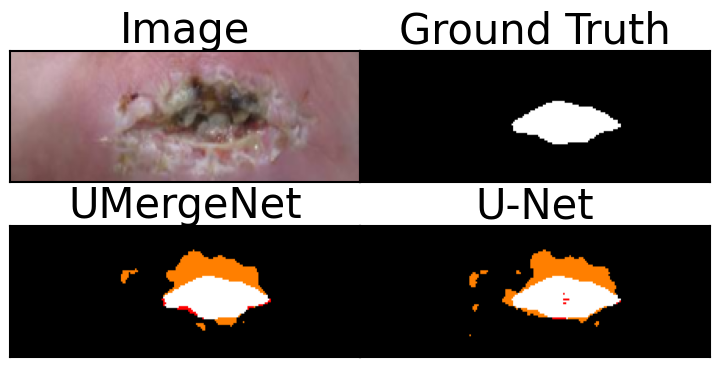

In [58]:
#from ImageComparisonGenerator import ImageComparisonGenerator, load_model


def cut_images(im):
    im = im[40:110,]
    return im


model1 = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Axial)
model1 = load_model(model1,"./UMergeNet/UMergeNet-axial-1-epochs300-best.pth")


import sys
sys.path.append("/media/calculon/TUDAO/Image_Segmentation")
from network import U_Net
model2 = U_Net(img_ch=in_channels, output_ch=out_channels)
model2 = load_model(model2,"./colab_unets/UNet-2-epochs300-best.pth")
# from DeepLabV3 import *
# model2 = DeepLabV3MobilenetV2Wrapper(in_channels=in_channels, out_channels=out_channels)
# stats2 = load_model(model2,'./DeepLabV3/DeepLabV3MobilenetV2Wrapper-2-epochs300-best.pth')


icg = ImageComparisonGenerator(model=model1, model_name1="UMergeNet", model2=model2, model_name2="U-Net")
icg.save_output_quad(val_loader, samples=[0], do_diff=True, invert_diff_colors=True, do_save='fuseg-quad-0.eps', 
                     before_plot=cut_images, 
                     vertical_gap=0.25,
                     figsize=(7,3.5))

#predict_and_show_mask(model, val_loader,0)

/media/calculon/TUDAO/0UMergeNet/fuseg/../util/ImageComparisonGenerator.py:222: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,1,0.96])


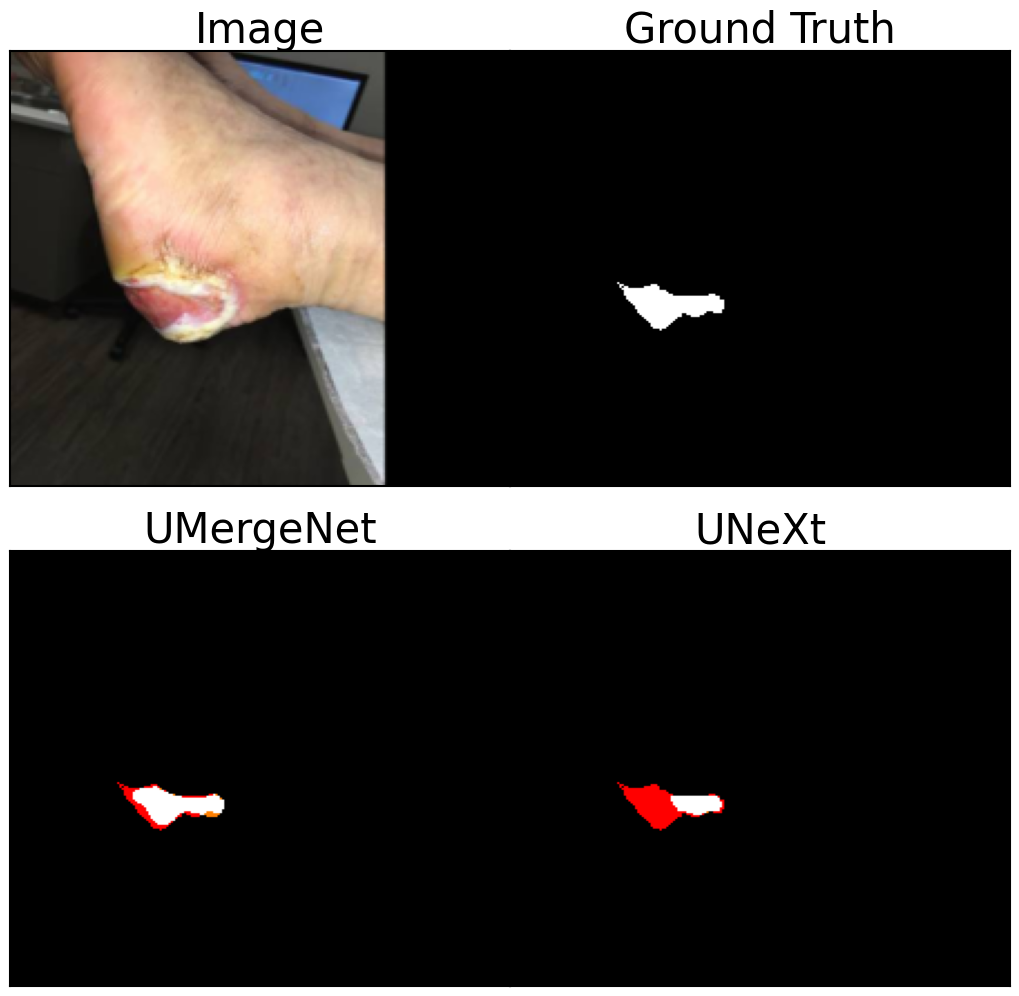

In [ ]:
from ImageComparisonGenerator import ImageComparisonGenerator, load_model

model = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Axial)
model1 = load_model(model,"./UMergeNet/UMergeNet-axial-1-epochs300-best.pth")


from UNext import *
model2 = UNext(input_channels=in_channels, num_classes=out_channels, img_size=config.dataset_resolution)
model2 = load_model(model2,'./UNext/UNext-2-epochs300-best.pth')
# import sys
# sys.path.append("/media/calculon/TUDAO/Image_Segmentation")
# from network import AttU_Net
# model2 = AttU_Net(img_ch=in_channels, output_ch=out_channels)
# model2 = load_model(model2,"./colab_unets/AttU_Net-1-best.pth")
# from DeepLabV3 import *
# model2 = DeepLabV3MobilenetV2Wrapper(in_channels=in_channels, out_channels=out_channels)
# stats2 = load_model(model2,'./DeepLabV3/DeepLabV3MobilenetV2Wrapper-2-epochs300-best.pth')


icg = ImageComparisonGenerator(model=model1, model_name1="UMergeNet", model2=model2, model_name2="UNeXt")
icg.save_output_quad(val_loader, samples=[1], do_diff=True, invert_diff_colors=True, do_save='fuseg-quad-1.eps')

#predict_and_show_mask(model, val_loader,0)

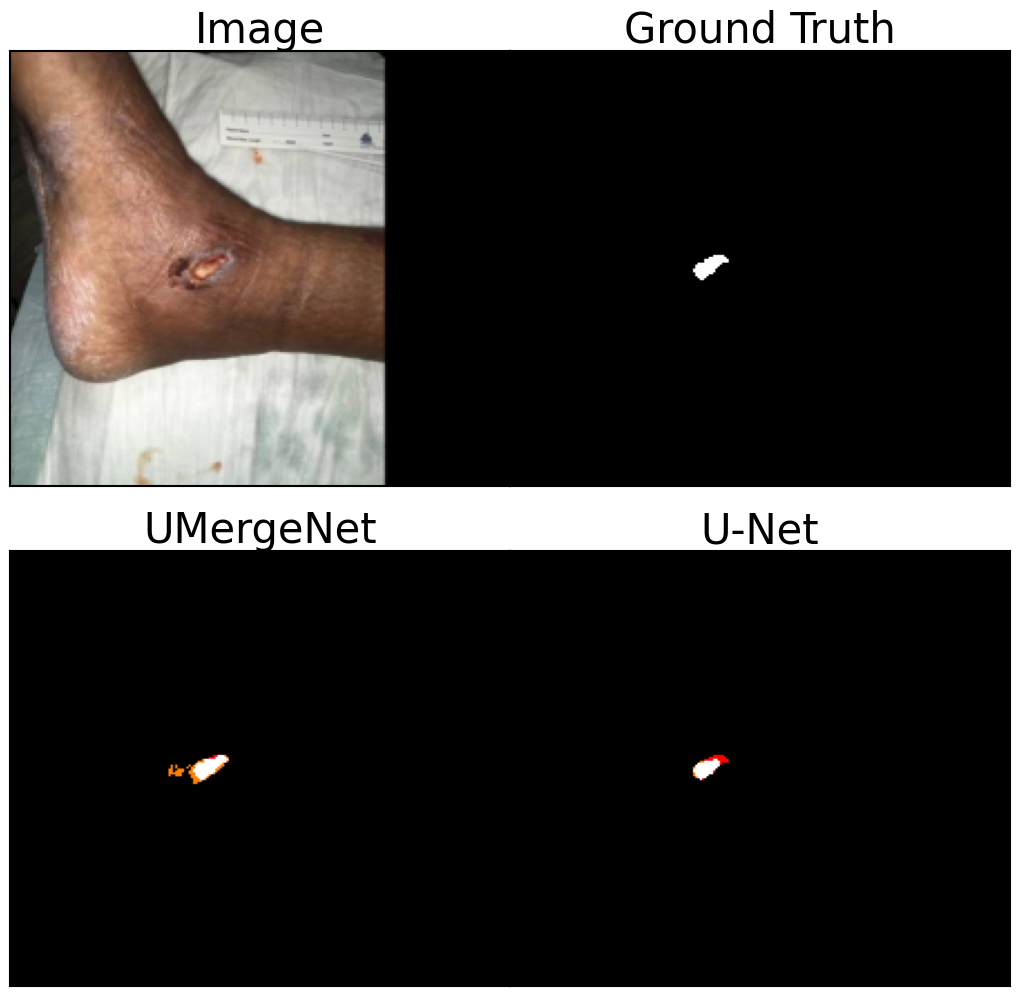

In [17]:
from ImageComparisonGenerator import ImageComparisonGenerator, load_model

model1 = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Axial)
model1 = load_model(model1,"./UMergeNet/UMergeNet-axial-1-epochs300-best.pth")

import sys
sys.path.append("/media/calculon/TUDAO/Image_Segmentation")
from network import U_Net
model2 = U_Net(img_ch=in_channels, output_ch=out_channels)
model2 = load_model(model2,"./colab_unets/UNet-2-epochs300-best.pth")

sample = 3
icg = ImageComparisonGenerator(model=model1, model_name1="UMergeNet", model2=model2, model_name2="U-Net")
icg.save_output_quad(test_loader, samples=[sample], do_diff=True, invert_diff_colors=True, do_save=f'fuseg-quad-{sample}.eps')

#predict_and_show_mask(model, val_loader,0)

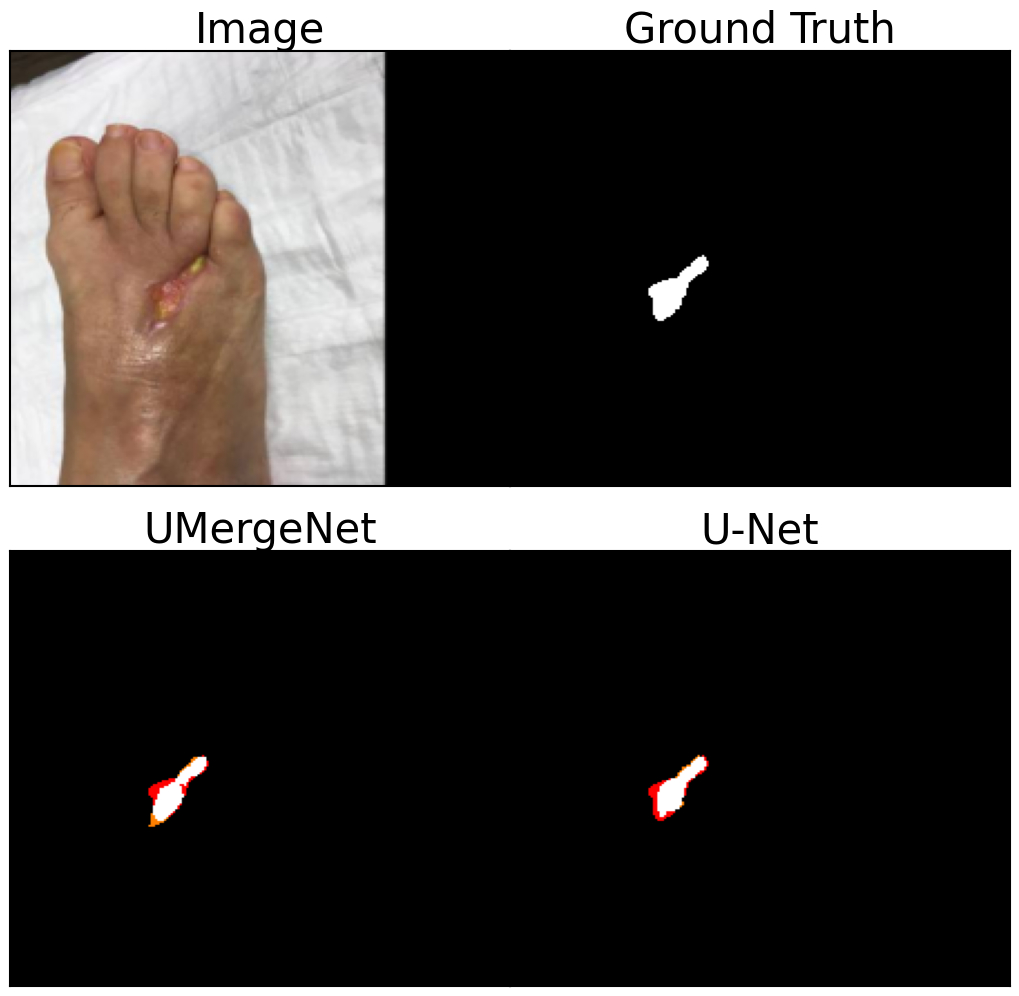

In [23]:
from ImageComparisonGenerator import ImageComparisonGenerator, load_model

model1 = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Axial)
model1 = load_model(model1,"./UMergeNet/UMergeNet-axial-1-epochs300-best.pth")

import sys
sys.path.append("/media/calculon/TUDAO/Image_Segmentation")
from network import U_Net
model2 = U_Net(img_ch=in_channels, output_ch=out_channels)
model2 = load_model(model2,"./colab_unets/UNet-2-epochs300-best.pth")

sample = 7
icg = ImageComparisonGenerator(model=model1, model_name1="UMergeNet", model2=model2, model_name2="U-Net")
icg.save_output_quad(test_loader, samples=[sample], do_diff=True, invert_diff_colors=True, do_save=f'fuseg-quad-{sample}.eps')

#predict_and_show_mask(model, val_loader,0)

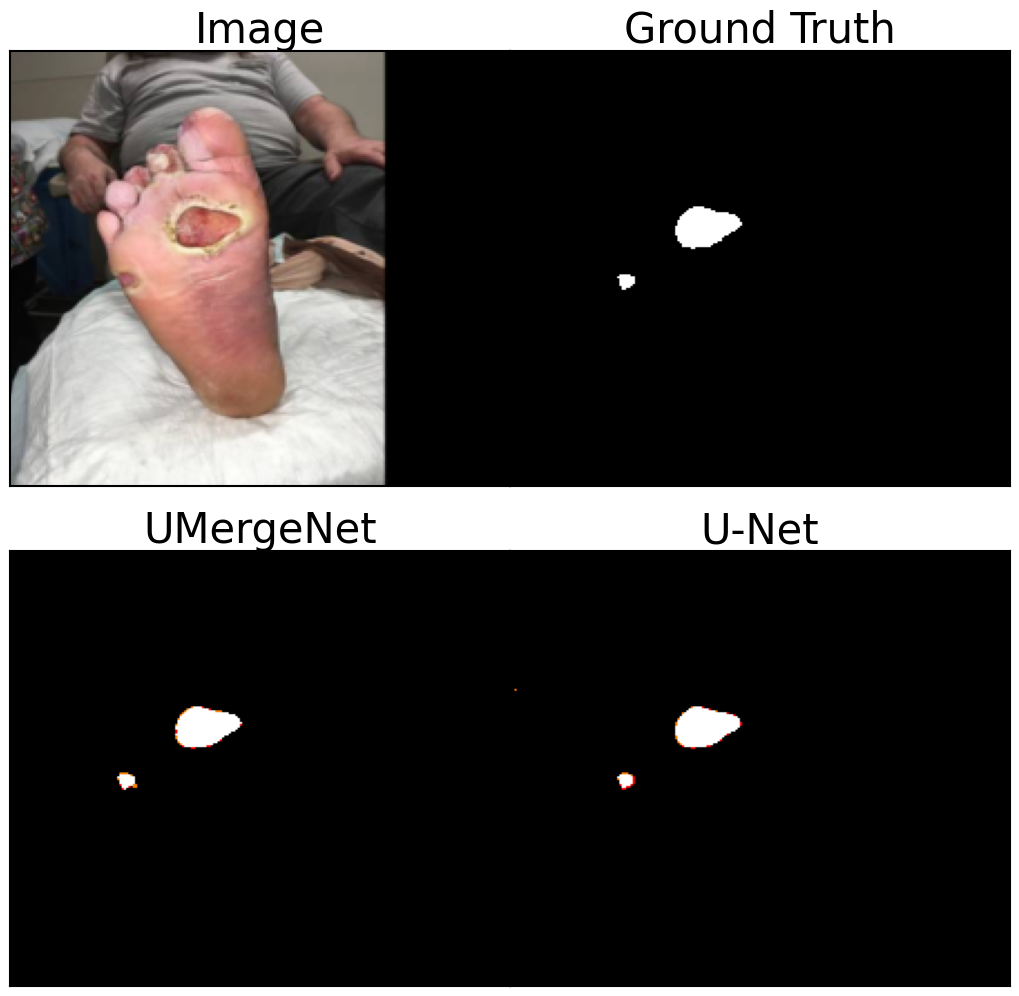

In [ ]:
from ImageComparisonGenerator import ImageComparisonGenerator, load_model

model1 = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Axial)
model1 = load_model(model1,"./UMergeNet/UMergeNet-axial-1-epochs300-best.pth")

import sys
sys.path.append("/home/calculon/0TUDAO/Image_Segmentation")
from network import U_Net
model2 = U_Net(img_ch=in_channels, output_ch=out_channels)
model2 = load_model(model2,"./colab_unets/UNet-2-epochs300-best.pth")

sample = 14
icg = ImageComparisonGenerator(model=model1, model_name1="UMergeNet", model2=model2, model_name2="U-Net")
icg.save_output_quad(test_loader, samples=[sample], do_diff=True, invert_diff_colors=True, do_save=f'fuseg-quad-{sample}.eps')

#predict_and_show_mask(model, val_loader,0)

/home/calculon/0TUDAO/0UMergeNet/fuseg/../util/ImageComparisonGenerator.py:201: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,1,0.96])


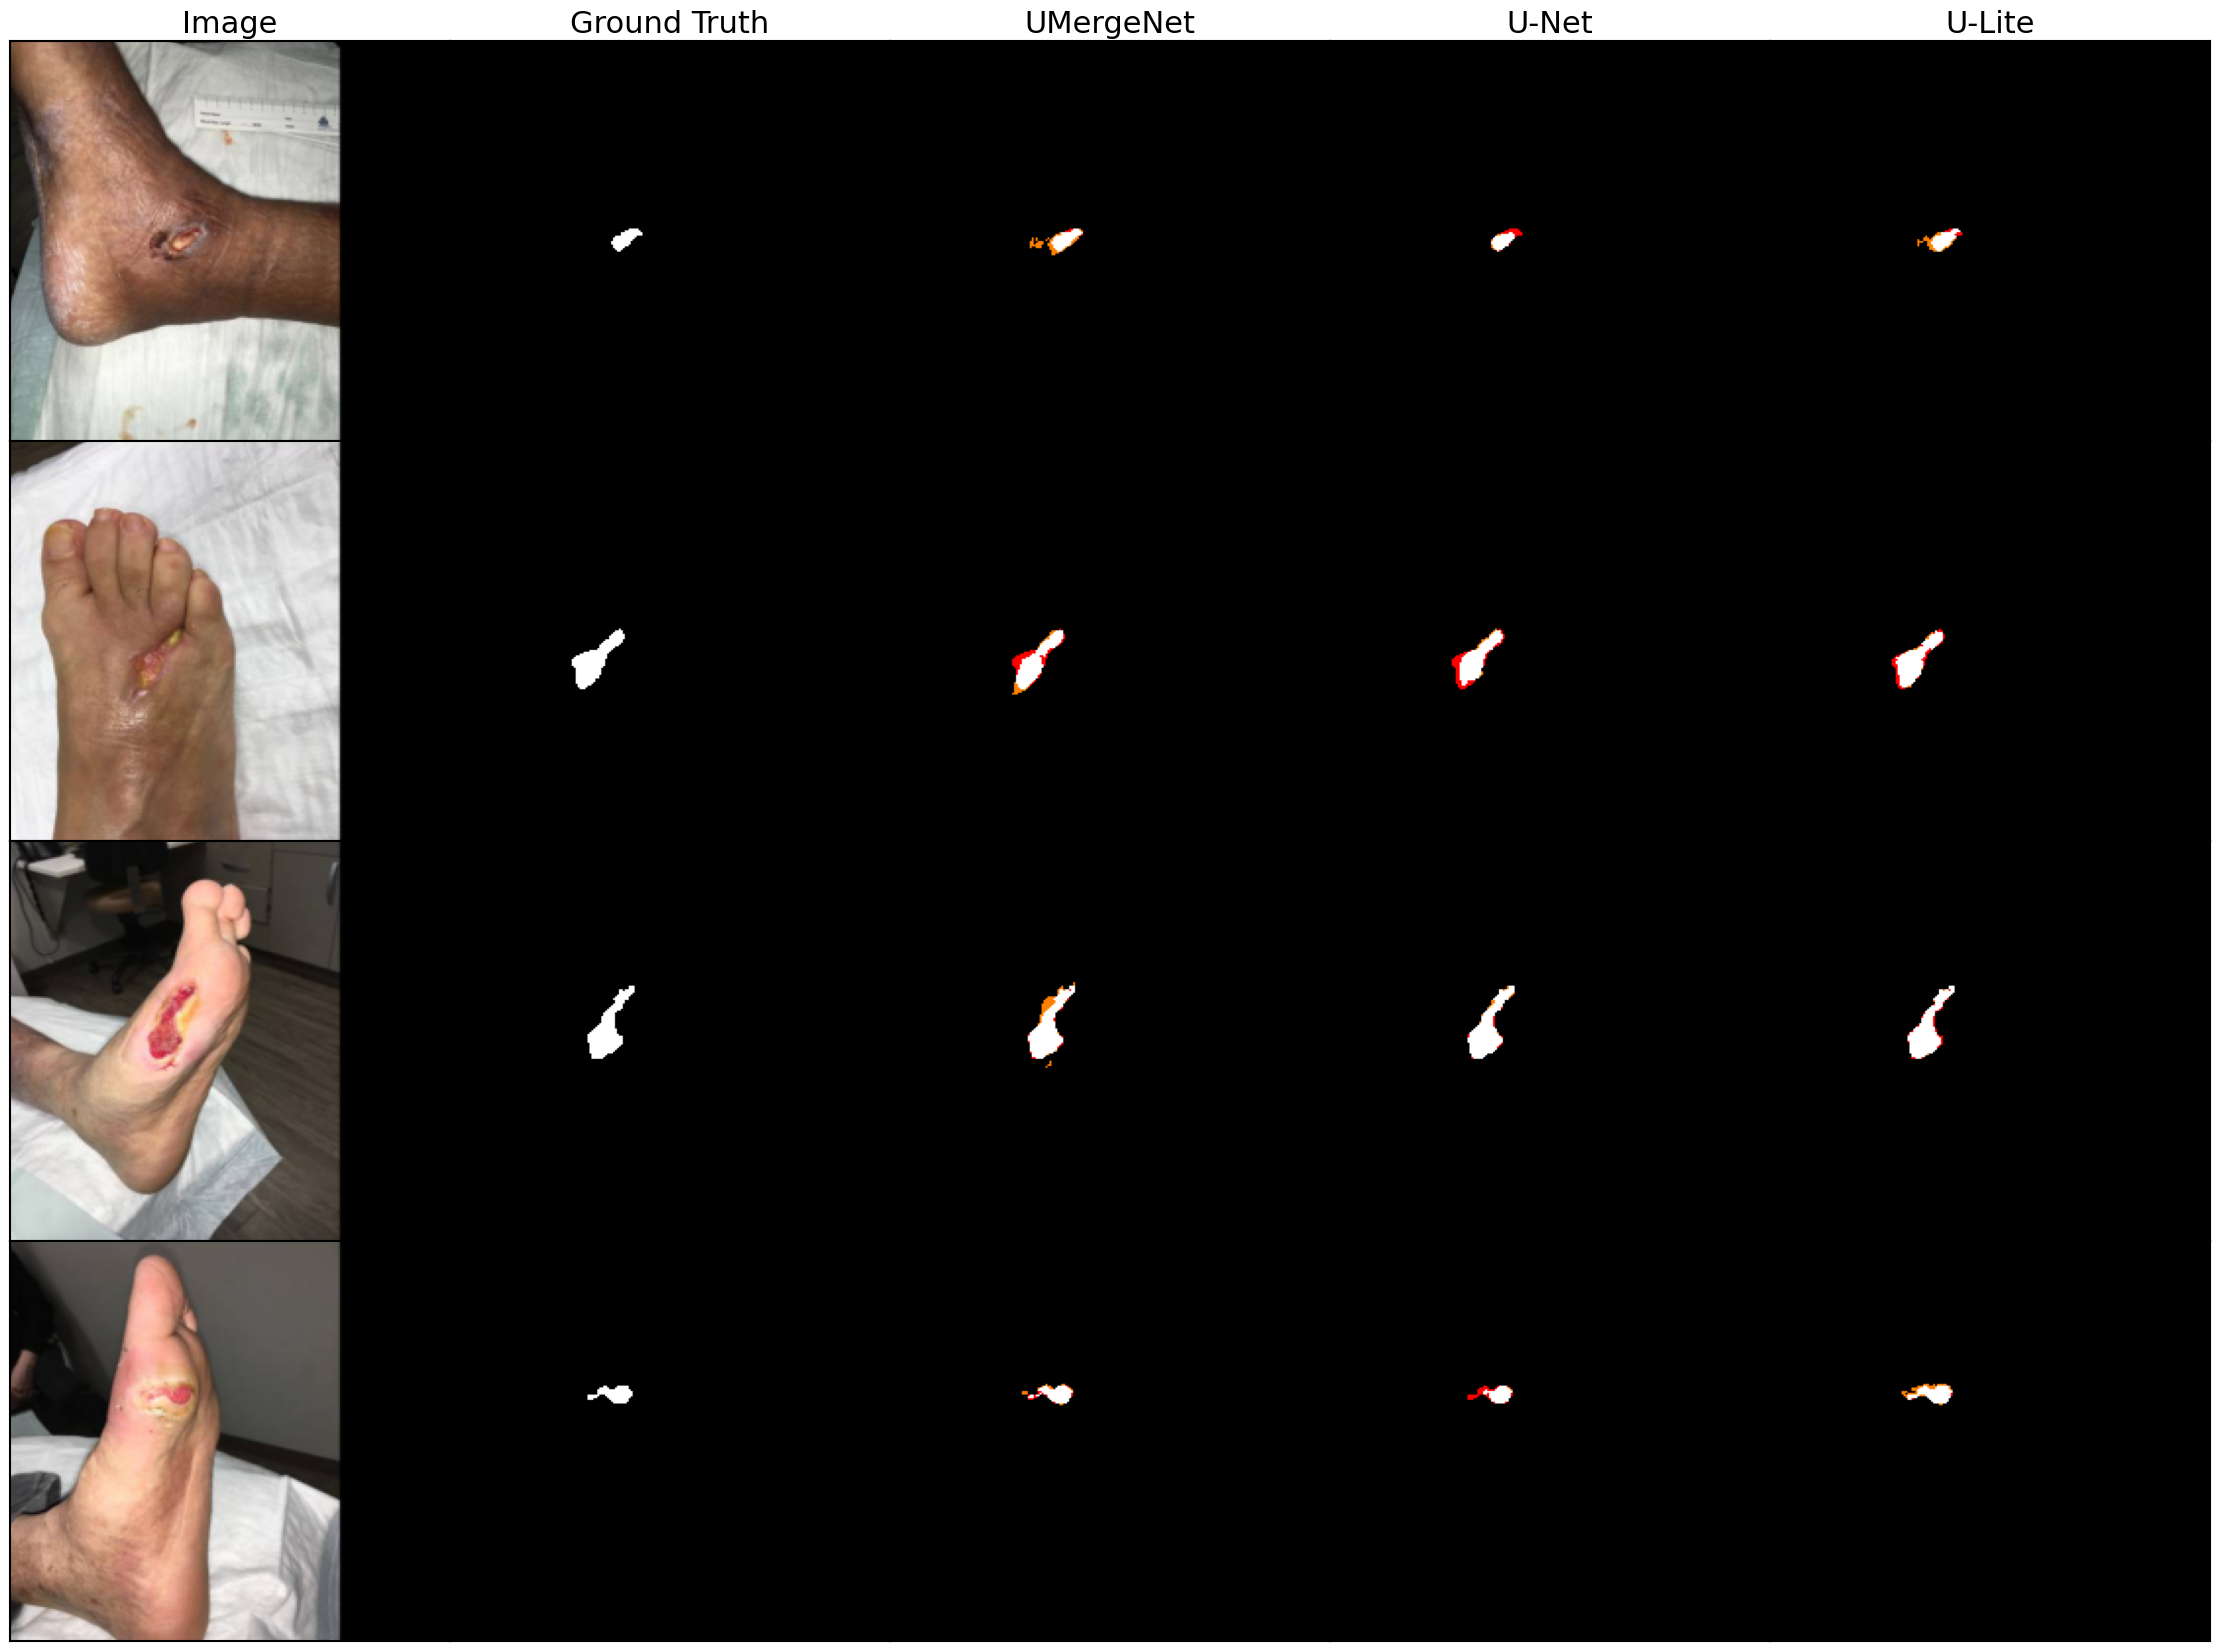

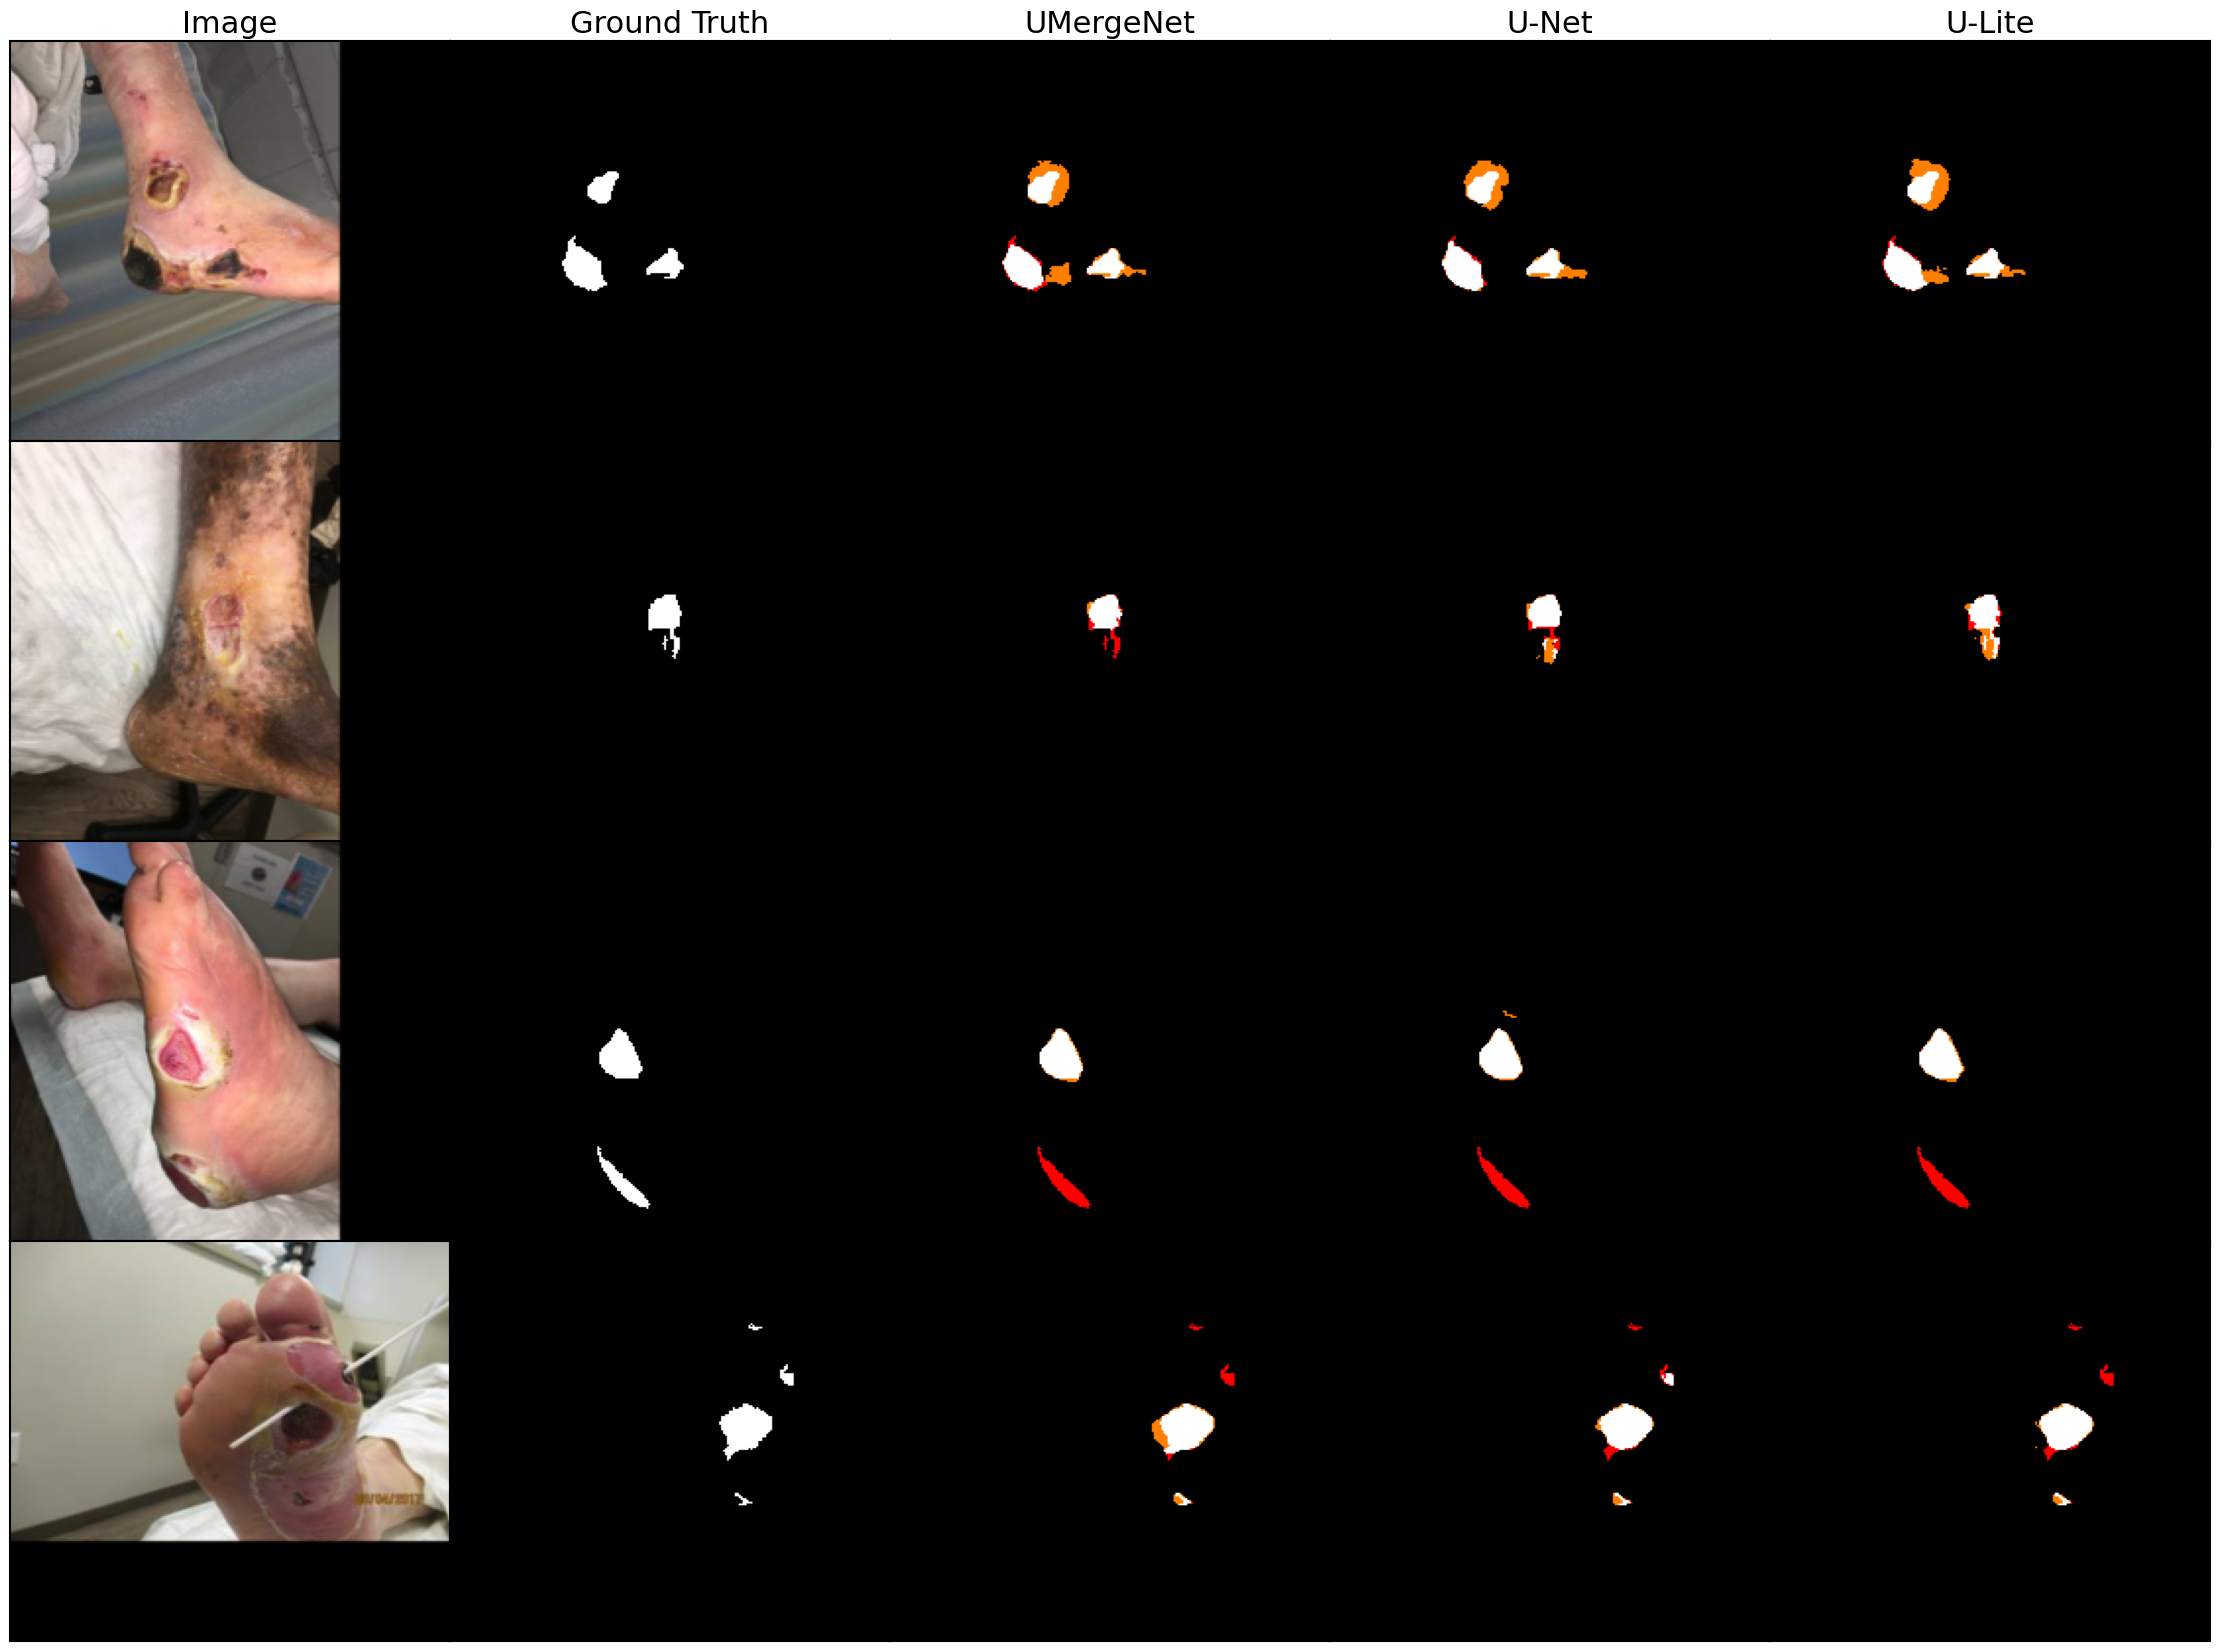

In [4]:
from ImageComparisonGenerator import ImageComparisonGenerator, load_model, combine_images


model1 = UMergeNet(in_channels=in_channels, out_channels=out_channels, conv_type=ConvType.Axial)
model1 = load_model(model1,"./UMergeNet/UMergeNet-axial-1-epochs300-best.pth")


import sys
sys.path.append("/home/calculon/0TUDAO/Image_Segmentation")
from network import U_Net
model2 = U_Net(img_ch=in_channels, output_ch=out_channels)
model2 = load_model(model2,"./colab_unets/UNet-2-epochs300-best.pth")

from ULite import *
model3 = ULite(in_channels=in_channels, out_channels=out_channels)
model3 = load_model(model3,"./ULite/ULite-3-epochs300-best.pth")

#from UNext import *
#model3 = UNext(input_channels=in_channels, num_classes=out_channels, img_size=config.dataset_resolution)
#model3 = load_model(model3,"./UNext/UNext-2-epochs300-best.pth")

icg = ImageComparisonGenerator(model=model1, model_name1="UMergeNet", model2=model2, model_name2="U-Net", model3=model3, model_name3="U-Lite")
icg.save_output_row(test_loader, samples=[3, 7, 11, 13], do_diff=True, invert_diff_colors=True, do_save='fuseg-list-p1.eps')
icg.save_output_row(test_loader, samples=[18, 19, 20, 29], do_diff=True, invert_diff_colors=True, do_save='fuseg-list-p2.eps')

#combine_images('fuseg-list-p1-new.eps', 'fuseg-list-p2-new.eps', 'fuseg-list-combined-new.eps')
